In [1]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from torch.amp import GradScaler, autocast
import matplotlib.pyplot as plt

# Device configuration: NVIDIA GPU (Kaggle/Colab) -> Apple Silicon GPU -> CPU
if torch.cuda.is_available():
    device = torch.device("cuda:0")
    torch.backends.cudnn.benchmark = True
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

# Mixed precision only helps on CUDA; MPS and CPU train in float32
use_amp = device.type == 'cuda'
print(f"Accelerating on: {device} (AMP: {use_amp})")

Accelerating on: mps (AMP: False)


In [2]:
# RAF-DB colour dataset laid out as <data_dir>/train/1..7 and <data_dir>/test/1..7
# Uses the Kaggle input when running on Kaggle, otherwise the local copy in ../data/raf-db
kaggle_dir = '/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET'
data_dir = kaggle_dir if os.path.isdir(kaggle_dir) else '../data/raf-db'

# Notice: Grayscale is REMOVED because RAF-DB provides high-quality RGB images
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

image_datasets = {x: datasets.ImageFolder(f'{data_dir}/{x}', data_transforms[x]) for x in ['train', 'test']}
dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=64, shuffle=(x == 'train'), num_workers=2,
                  pin_memory=use_amp, persistent_workers=True)
    for x in ['train', 'test']
}

class_names = image_datasets['train'].classes
# RAF-DB label meanings for folders '1'..'7' (same order as the video inference scripts)
emotion_names = ['Surprise', 'Fear', 'Disgust', 'Happy', 'Sad', 'Anger', 'Neutral']
print(f"Detected Classes: {class_names}")
print(f"Train images: {len(image_datasets['train'])}, Test images: {len(image_datasets['test'])}")

Detected Classes: ['1', '2', '3', '4', '5', '6', '7']
Train images: 12271, Test images: 3068


In [3]:
# Load Pretrained EfficientNet-B0
model = models.efficientnet_b0(weights='IMAGENET1K_V1')

# EfficientNet's head is classifier = [Dropout, Linear(1280, 1000)]
num_ftrs = model.classifier[1].in_features

# Same Dropout + Linear head as the ResNet and DenseNet RAF-DB models
model.classifier = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(num_ftrs, len(class_names))
)

model = model.to(device)

In [4]:
epochs = 12
criterion = nn.CrossEntropyLoss(label_smoothing=0.1) # Label smoothing handles noisy labels in datasets

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=1e-3,
    steps_per_epoch=len(dataloaders['train']),
    epochs=epochs
)

In [5]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=15):
    # With enabled=False (MPS/CPU) the scaler and autocast are no-ops
    scaler = GradScaler(device.type, enabled=use_amp)
    total_steps_limit = num_epochs * len(dataloaders['train'])
    current_step = 0

    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        epoch_start = time.time()
        for phase in ['train', 'test']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss, running_corrects = 0.0, 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    with autocast(device.type, enabled=use_amp):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                    if phase == 'train':
                        scaler.scale(loss).backward()

                        before_step_scale = scaler.get_scale()
                        scaler.step(optimizer)
                        scaler.update()

                        if current_step < total_steps_limit:
                            if scaler.get_scale() >= before_step_scale:
                                scheduler.step()
                                current_step += 1

                running_loss += loss.item() * inputs.size(0)
                # Count as a Python int: MPS does not support float64 tensors
                running_corrects += (preds == labels).sum().item()

            epoch_loss = running_loss / len(image_datasets[phase])
            epoch_acc = running_corrects / len(image_datasets[phase])

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc)
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
        print(f'Epoch time: {time.time() - epoch_start:.0f}s')

    return model, history

model, history = train_model(model, criterion, optimizer, scheduler, num_epochs=epochs)

Epoch 1/12


train Loss: 1.6130 Acc: 0.4353


test Loss: 1.2166 Acc: 0.6437
Epoch time: 215s
Epoch 2/12


train Loss: 1.0980 Acc: 0.6987


test Loss: 0.9598 Acc: 0.7559
Epoch time: 209s
Epoch 3/12


...

test Loss: 0.7644 Acc: 0.8654
Epoch time: 231s
Epoch 11/12


train Loss: 0.4976 Acc: 0.9863


test Loss: 0.7560 Acc: 0.8765
Epoch time: 229s
Epoch 12/12


train Loss: 0.4922 Acc: 0.9881


test Loss: 0.7621 Acc: 0.8742
Epoch time: 226s


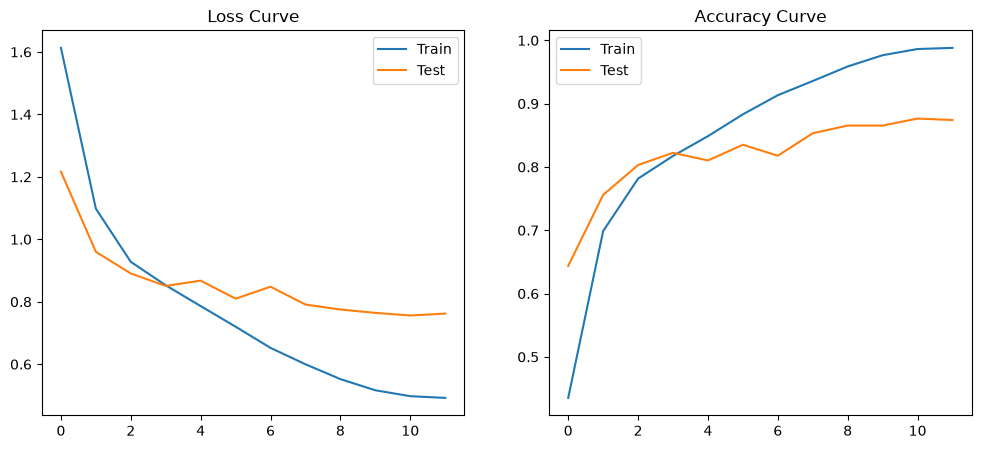

✅ RAF-DB Model saved successfully to 'efficientnet_b0_rafdb_final.pth'


In [6]:
# Plot Training History
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train')
plt.plot(history['test_loss'], label='Test')
plt.title('Loss Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train')
plt.plot(history['test_acc'], label='Test')
plt.title('Accuracy Curve')
plt.legend()
plt.show()

# Save the RAF-DB trained model
torch.save(model.state_dict(), 'efficientnet_b0_rafdb_final.pth')
print("✅ RAF-DB Model saved successfully to 'efficientnet_b0_rafdb_final.pth'")

In [7]:
# Per-class accuracy on the RAF-DB test set
model.eval()
correct = torch.zeros(len(class_names), dtype=torch.long)
total = torch.zeros(len(class_names), dtype=torch.long)

with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        preds = model(inputs.to(device)).argmax(1).cpu()
        total += torch.bincount(labels, minlength=len(class_names))
        correct += torch.bincount(labels[preds == labels], minlength=len(class_names))

print(f"Overall test accuracy: {correct.sum().item() / total.sum().item():.4f}\n")
for folder, name, c, t in zip(class_names, emotion_names, correct.tolist(), total.tolist()):
    print(f"{folder} {name:<9} {c / t:.4f}  ({c}/{t})")

Overall test accuracy: 0.8742

1 Surprise  0.8663  (285/329)
2 Fear      0.6081  (45/74)
3 Disgust   0.6500  (104/160)
4 Happy     0.9274  (1099/1185)
5 Sad       0.8745  (418/478)
6 Anger     0.8210  (133/162)
7 Neutral   0.8794  (598/680)
